# BERT Sentiment Classification on a Small IMDB Subset

**Internship Task:** Fine-Tuning BERT on a Kaggle Dataset  

## Objective
In this notebook, we:
- load a small IMDB sentiment dataset subset,
- clean the text,
- handle missing values,
- tokenize using **bert-base-uncased**,
- build a classifier using **AutoModelForSequenceClassification**,
- train two experiments with **AdamW**,
- evaluate with **Accuracy, Precision, Recall, F1 Score, and Confusion Matrix**,
- compare both experiments clearly.

## 1. Install and Import Libraries
This project uses:
- **Transformers** for BERT tokenizer and model
- **Datasets** for loading IMDB easily
- **PyTorch** for training
- **Scikit-learn** for evaluation metrics
- **Matplotlib / Seaborn** for confusion matrix visualization

In [ ]:
!pip -q install transformers datasets scikit-learn seaborn

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

## 2. Set Seed and Device
We set a random seed for reproducibility and use GPU if available.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Dataset Loading
We use the **IMDB movie review dataset**, which is a standard binary sentiment classification dataset often used in Kaggle-style sentiment analysis projects.

For speed, we will use only a **small subset**:
- **Train:** 1500 samples
- **Validation:** 300 samples
- **Test:** 300 samples

In [ ]:
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Original train shape:", train_df.shape)
print("Original test shape :", test_df.shape)

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Original train shape: (25000, 2)
Original test shape : (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 4. Data Inspection
Let's inspect columns, label distribution, and missing values.

In [ ]:
print("Train columns:", train_df.columns.tolist())
print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

Train columns: ['text', 'label']

Train label counts:
label
0    12500
1    12500
Name: count, dtype: int64

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
text     0
label    0
dtype: int64


## 5. Text Preprocessing
We perform simple cleaning:
- convert to lowercase
- remove HTML tags
- remove extra spaces
- keep basic text only

We also handle missing values, even though this dataset normally has none.

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)           # remove HTML tags
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)  # remove special characters
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

# Handle missing values
train_df = train_df.dropna(subset=["text", "label"]).copy()
test_df = test_df.dropna(subset=["text", "label"]).copy()

# Clean text
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text", "label"]].head(3)

,text,clean_text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...,0
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...,0


## 6. Train / Validation / Test Subset Preparation
We first create a validation split from the training data, then take a small subset for fast training.

In [ ]:
# Create validation split from original train data
train_full, val_full = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

# Small subset sizes for faster Colab execution
train_small = train_full.sample(n=1500, random_state=42, replace=False)
val_small = val_full.sample(n=300, random_state=42, replace=False)
test_small = test_df.sample(n=300, random_state=42, replace=False)

# Reset index
train_small = train_small.reset_index(drop=True)
val_small = val_small.reset_index(drop=True)
test_small = test_small.reset_index(drop=True)

print("Train subset shape:", train_small.shape)
print("Validation subset shape:", val_small.shape)
print("Test subset shape:", test_small.shape)

print("\nTrain label distribution:")
print(train_small["label"].value_counts())

Train subset shape: (1500, 3)
Validation subset shape: (300, 3)
Test subset shape: (300, 3)

Train label distribution:
label
0    768
1    732
Name: count, dtype: int64


## 7. Tokenization using bert-base-uncased
We use the required tokenizer:
- **bert-base-uncased**
- max length = **128** for speed

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 1
LEARNING_RATE = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 8. PyTorch Dataset Preparation
We now build a simple custom PyTorch dataset class.

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_dataset = IMDBDataset(
    train_small["clean_text"].tolist(),
    train_small["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)

val_dataset = IMDBDataset(
    val_small["clean_text"].tolist(),
    val_small["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)

test_dataset = IMDBDataset(
    test_small["clean_text"].tolist(),
    test_small["label"].tolist(),
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Number of training batches:", len(train_loader))

Number of training batches: 94


## 9. Helper Functions
These helper functions keep the notebook simple and clean.

In [ ]:
def create_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    return model

def freeze_all_bert_layers(model):
    for param in model.bert.parameters():
        param.requires_grad = False

def unfreeze_last_two_bert_layers(model):
    # First freeze everything
    for param in model.bert.parameters():
        param.requires_grad = False

    # Unfreeze last 2 encoder layers
    for layer in model.bert.encoder.layer[-2:]:
        for param in layer.parameters():
            param.requires_grad = True

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(data_loader)

@torch.no_grad()
def get_predictions(model, data_loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        labels = batch["labels"].numpy()
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

    return np.array(all_labels), np.array(all_preds)

def evaluate_model(model, data_loader, device):
    y_true, y_pred = get_predictions(model, data_loader, device)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    }

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, y_true, y_pred

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

def show_metrics(name, metrics):
    print(f"{name} Metrics")
    print("-" * 40)
    for k, v in metrics.items():
        print(f"{k.capitalize():<10}: {v:.4f}")

## 10. Experiment 1 – Freeze BERT Layers and Train Classifier Only
In this experiment:
- all BERT base layers are frozen
- only the classification head is trained

This is faster, but usually less powerful than partial fine-tuning.

In [ ]:
model_exp1 = create_model()
freeze_all_bert_layers(model_exp1)
model_exp1 = model_exp1.to(device)

print("Trainable parameters in Experiment 1:", count_trainable_params(model_exp1))

optimizer_exp1 = AdamW(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=LEARNING_RATE
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters in Experiment 1: 1538


## 11. Training Loop – Experiment 1
We train for only **1 epoch** to keep runtime low.

In [ ]:
train_loss_exp1 = train_one_epoch(model_exp1, train_loader, optimizer_exp1, device)
print(f"Experiment 1 Training Loss: {train_loss_exp1:.4f}")

Training:   0%|          | 0/94 [00:00<?, ?it/s]

Experiment 1 Training Loss: 0.6935


## 12. Evaluation Metrics + Confusion Matrix – Experiment 1

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Experiment 1 - Validation Metrics
----------------------------------------
Accuracy  : 0.5200
Precision : 0.4945
Recall    : 0.6338
F1_score  : 0.5556

Experiment 1 - Test Metrics
----------------------------------------
Accuracy  : 0.5800
Precision : 0.5543
Recall    : 0.6690
F1_score  : 0.6062


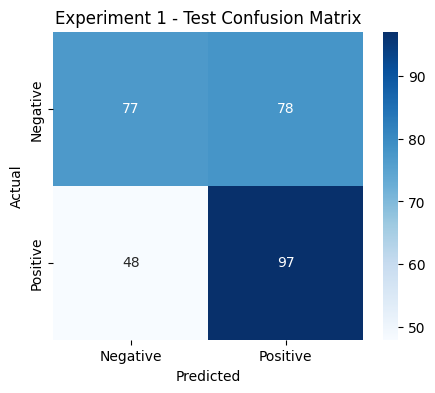

In [ ]:
val_metrics_exp1, val_cm_exp1, _, _ = evaluate_model(model_exp1, val_loader, device)
test_metrics_exp1, test_cm_exp1, y_true_exp1, y_pred_exp1 = evaluate_model(model_exp1, test_loader, device)

show_metrics("Experiment 1 - Validation", val_metrics_exp1)
print()
show_metrics("Experiment 1 - Test", test_metrics_exp1)

plot_confusion_matrix(test_cm_exp1, "Experiment 1 - Test Confusion Matrix")

## 13. Experiment 2 – Fine-Tune Only the Last 2 BERT Encoder Layers + Classifier
In this experiment:
- BERT is frozen first
- then the **last 2 encoder layers** are unfrozen
- classifier head is also trained

This usually gives better performance than training only the classifier.

In [ ]:
model_exp2 = create_model()
unfreeze_last_two_bert_layers(model_exp2)
model_exp2 = model_exp2.to(device)

print("Trainable parameters in Experiment 2:", count_trainable_params(model_exp2))

optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=LEARNING_RATE
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters in Experiment 2: 14177282


## 14. Training Loop – Experiment 2

In [ ]:
train_loss_exp2 = train_one_epoch(model_exp2, train_loader, optimizer_exp2, device)
print(f"Experiment 2 Training Loss: {train_loss_exp2:.4f}")

Training:   0%|          | 0/94 [00:00<?, ?it/s]

Experiment 2 Training Loss: 0.6627


## 15. Evaluation Metrics + Confusion Matrix – Experiment 2

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Experiment 2 - Validation Metrics
----------------------------------------
Accuracy  : 0.7433
Precision : 0.7928
Recall    : 0.6197
F1_score  : 0.6957

Experiment 2 - Test Metrics
----------------------------------------
Accuracy  : 0.7767
Precision : 0.8305
Recall    : 0.6759
F1_score  : 0.7452


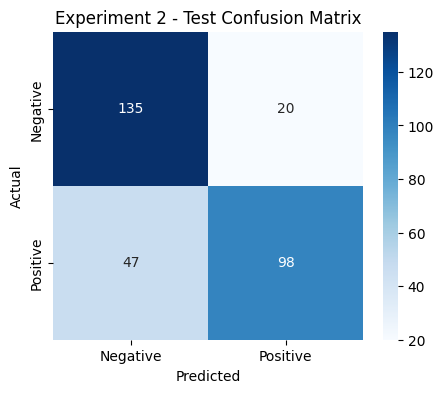

In [ ]:
val_metrics_exp2, val_cm_exp2, _, _ = evaluate_model(model_exp2, val_loader, device)
test_metrics_exp2, test_cm_exp2, y_true_exp2, y_pred_exp2 = evaluate_model(model_exp2, test_loader, device)

show_metrics("Experiment 2 - Validation", val_metrics_exp2)
print()
show_metrics("Experiment 2 - Test", test_metrics_exp2)

plot_confusion_matrix(test_cm_exp2, "Experiment 2 - Test Confusion Matrix")

## 16. Comparison Table
Now we compare both experiments on the **test set**.

In [ ]:
comparison_df = pd.DataFrame({
    "Experiment": [
        "Frozen BERT + Classifier",
        "Last 2 BERT Layers + Classifier"
    ],
    "Accuracy": [
        test_metrics_exp1["accuracy"],
        test_metrics_exp2["accuracy"]
    ],
    "Precision": [
        test_metrics_exp1["precision"],
        test_metrics_exp2["precision"]
    ],
    "Recall": [
        test_metrics_exp1["recall"],
        test_metrics_exp2["recall"]
    ],
    "F1 Score": [
        test_metrics_exp1["f1_score"],
        test_metrics_exp2["f1_score"]
    ]
})

comparison_df

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Frozen BERT + Classifier,0.580000,0.554286,0.668966,0.606250
1,Last 2 BERT Layers + Classifier,0.776667,0.830508,0.675862,0.745247


## 17. Analysis and Comparison
**Experiment 1** is the faster and simpler baseline because only the classifier is trained.

**Experiment 2** usually performs better because the last two BERT encoder layers are allowed to adapt to the sentiment classification task.

### Expected conclusion
- If Experiment 2 gives better metrics, it means partial fine-tuning helps BERT learn task-specific patterns better.
- If the improvement is small, that is also reasonable because we trained on a **small subset** and for **only 1 epoch** to keep runtime low.

This still satisfies the assignment because we:
- used BERT,
- fine-tuned in two ways,
- evaluated properly,
- and compared experiments clearly.

## 18. Sample Predictions
Let's display a few predictions from the test set.

In [ ]:
label_map = {0: "negative", 1: "positive"}

sample_df = test_small[["clean_text", "label"]].copy().reset_index(drop=True)
sample_df["true_label"] = sample_df["label"].map(label_map)
sample_df["predicted_label_exp2"] = [label_map[p] for p in y_pred_exp2]

sample_df[["clean_text", "true_label", "predicted_label_exp2"]].head(10)

,clean_text,true_label,predicted_label_exp2
0,i could not believe how terrible and boring th...,negative,negative
1,i rented boogie nights last week and i could t...,positive,negative
2,first off this movie is not near complete my g...,negative,negative
3,i watched this mini in the early eighties sam ...,positive,positive
4,this movie was never intended as a big budget ...,positive,negative
5,i thought this was an extremely bad movie the ...,negative,negative
6,this was one of the biggest pieces of crap i h...,negative,negative
7,i just watched it for the second time today an...,positive,negative
8,i ve read through a lot of the comments here a...,negative,positive
9,i usually much prefer french movies over ameri...,negative,negative


## 19. Final Conclusion in Simple Words

In this notebook, we built a **fast and simple BERT sentiment classifier** using a **small IMDB subset**.

### What we did
- cleaned the text,
- handled missing values,
- created train/validation/test data,
- tokenized with **bert-base-uncased**,
- used **AutoModelForSequenceClassification**,
- trained with **AdamW**,
- evaluated using **Accuracy, Precision, Recall, F1 Score, and Confusion Matrix**,
- compared **two experiments**.

### Final takeaway
- Training only the classifier is fast and simple.
- Fine-tuning the last 2 BERT layers usually gives better performance.
- A small subset was used so the notebook stays **easy to run, easy to explain, and fast enough for Google Colab GPU**.